# 5. Long-Term Memory

[Summary]

| Date | User | Change Type | Remarks |  
| ---- | ---- | ----------- | ------- |
| 05/06/2026   | Martin | CREATE   | Notebook for Langgraph module 5 created. | 
| 08/06/2026   | Martin | UPDATE   | Completed Chatbot with memory. Started profile schema | 

# Content

* [Short vs. Long Term Memory](#short-vs-long-term-memory)
* [Chatbot with Memory](#chatbot-with-memory)
* [Chatbot with Profile Schema](#chatbot-with-profile-schema)

# Short vs. Long Term Memory

Memory is an LLM/ Agent's ability to preserve information between chats with the user.

- __Short-Term Memory__: `Checkpointer`. The LLM/Agent's ability to remember information from the current session. It persists conversational history (e.g if user is idle, human-in-the-loop responses)
- __Long-Term Memory__: `Store`. The LLM/Agent's ability to remember information from previous sessions. Remembers information about the user. (e.g user profile, info from previous sessions)

Information can be taken from both short-term and long-term memory.

For short-term memory management, it's usually about _managing chat history_. Functions like `summarise` or `filter` are used.

## Long-Term Memory

One way to selecting how to process memory is to ask 2 questions: What is the type of memory? When do you want to update memory?

<u>Types of Memory</u>

1. __Semantic Memory (Facts)__ - Facts about the world. There are 2 ways to represent this:
    - _Profile:_ A profile is like a set of facts about a thing. Information is stored as a single document with properties added and updated as the agent learns about the user. 
        - ✅ Easily retrieved as a single representation.
        - ❌ Challenging to maintain as it grows larger. (e.g User profile)
    - _List:_ A collection of items asked to be stored by the user. Items can be added or removed as necessary.
        - ✅ Allows for smaller, narrowly scoped memories.
        - ❌ Retrieval can be challenging as list grows larger. (e.g Shopping list)
2. __Episodic Memory (Events)__ - Past agent actions. It can help improve how the agent interacts with the environment e.g the their tool calls, how to engage with environment
3. __Procedural Memory (Instructions)__ - Improve the agents thinking process. It iteratively improves it's system prompts from the feedback given by the user in the background.

---

# Chatbot with Memory

`Langgraph Memory Store` provides a way to store and retrieve information across thread in Langgraph. A `key-value` store

## LangGraph store

When storing objects, this is the convention:

- `namespace`: Grouping for all objects in the store. Like a directory.
- `key`: Idenfier for an object. Like the filename
- `value`: Contents of the object. Like the file contents.

[img]

In [13]:
import os
import uuid
from pydantic import SecretStr
from dotenv import load_dotenv
from pprint import pprint

from langgraph.store.memory import InMemoryStore
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.graph import StateGraph, MessagesState
from langgraph.constants import START, END
from langgraph.store.base import BaseStore
from langchain_groq import ChatGroq

from langchain_core.messages import HumanMessage, SystemMessage
from langchain_core.runnables.config import RunnableConfig

from IPython.display import display, Image
in_memory_store = InMemoryStore()
load_dotenv()

True

In [2]:
# Namespace for the memory to save
user_id = "1"
namespace = (user_id, "memories") # Each unique user's memories are stored in a single namespace

# Key-value memory
key = str(uuid.uuid4())
value = {"food_preference": "I like pizza"}

# Store in memory - PUT
in_memory_store.put(namespace, key, value)

In [3]:
# Search the store
memories = in_memory_store.search(namespace)
print(type(memories))

# Metadata
print(memories[0].dict())

# Key-values are stored as dictionaries
print(memories[0].key, memories[0].value)

<class 'list'>
{'namespace': ['1', 'memories'], 'key': '95d0303d-16f5-4273-a51b-9971ea8813e9', 'value': {'food_preference': 'I like pizza'}, 'created_at': '2026-06-08T13:06:09.572536+00:00', 'updated_at': '2026-06-08T13:06:09.572536+00:00', 'score': None}
95d0303d-16f5-4273-a51b-9971ea8813e9 {'food_preference': 'I like pizza'}


In [4]:
# Get the memory by namespace and key
memory = in_memory_store.get(namespace, key)
if memory is not None:
    pprint(memory.dict())

{'created_at': '2026-06-08T13:06:09.572536+00:00',
 'key': '95d0303d-16f5-4273-a51b-9971ea8813e9',
 'namespace': ['1', 'memories'],
 'updated_at': '2026-06-08T13:06:09.572536+00:00',
 'value': {'food_preference': 'I like pizza'}}


Build the chatbot instructions and functions

In [ ]:
API_KEY = SecretStr(os.getenv("GROQ_API_KEY", ""))
model = ChatGroq(
    model="llama-3.3-70b-versatile",
    api_key=API_KEY
)

In [6]:
# Used to inform prompts about memory
MODEL_SYSTEM_MESSAGE = """You are a helpful assistant with memory that provides information about the user.
If you have memory for this user, use it to personalise your responses.
Here is the memory (it may be empty): {memory}"""

# Used to create new memories
CREATE_MEMORY_INSTRUCTION = """You are collecting information about the user to personalise your responses.

CURRENT USER INFRORMATION:
{memory}

INSTRUCTIONS:
1. Review the chat history below carefully
2. Identify new information about the user, such as:
  - Personal details (name, location)
  - Preferences (likes, dislikes)
  - Interests and hobbies
  - Past exeperiences
  - Goals or future plans
3. Merge any new information with existing memory
4. Format memory as a clear, bulleted list
5. If new information conflicts with existing memory, keep the most recent version

Remember only inlcude factual information directly stated by user. Do not make assumptions or inferences.

Based on the chat history below, please update the user information
"""


In [7]:
def call_model(state: MessagesState, config: RunnableConfig, store: BaseStore):
    """Load memory from the store and use it personalise the chatbot's response"""
    # Get the user_id from config
    configurable = config.get("configurable", {})
    user_id = configurable.get("user_id", "")

    # Retrieve memory from the store
    namespace = ("memory", user_id)
    key = "user_memory"
    existing_memory = store.get(namespace, key)

    if existing_memory:
        existing_memory_content = existing_memory.value.get('memory')
    else:
        existing_memory_content = "No existing memory found"

    sys_message = MODEL_SYSTEM_MESSAGE.format(memory=existing_memory_content)
    response = model.invoke(
        [ SystemMessage(content=sys_message) ] + state['messages']
    )

    return {"messages": response}


def write_memory(state: MessagesState, config: RunnableConfig, store: BaseStore):
    """Reflect on the chat history and save a memory to the store"""
    # Get user_id from config
    configurable = config.get("configurable", {})
    user_id = configurable.get("user_id", "")

    # Retrieve existing memories
    namespace = ("memory", user_id)
    existing_memory = store.get(namespace, "user_memory")

    if existing_memory:
        existing_memory_content = existing_memory.value.get('memory')
    else:
        existing_memory_content = "No existing memory found."

    # Format the memory in system prompt
    sys_message = CREATE_MEMORY_INSTRUCTION.format(memory=existing_memory_content)
    new_memory = model.invoke(
        [ SystemMessage(content=sys_message) ] + state['messages']
    )

    # Overwrite key and value in the store
    key = "user_memory"
    print(repr(new_memory.content))
    store.put(namespace, key, {"memory": new_memory.content})


2 different stores for different types of memory:

1. `InMemorySaver`: Short-term (within-thread) memory. Requires `thread_id` for persisting the chat history
2. `InMemorySaver`: Long-term (cross-thread) memory. Requires the `user_id` to namespace long-term memories of the user


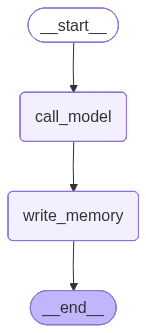

In [8]:
# Define the graph and memory
builder = StateGraph(MessagesState)
builder.add_node("call_model", call_model)
builder.add_node("write_memory", write_memory)

builder.add_edge(START, "call_model")
builder.add_edge("call_model", "write_memory")
builder.add_edge("write_memory", END)

# Memory portion
across_thread_memory = InMemoryStore() # For long-term memory
within_thread_memory = InMemorySaver() # For short-term memory

graph = builder.compile(checkpointer=within_thread_memory, store=across_thread_memory)

display(Image(graph.get_graph(xray=1).draw_mermaid_png()))


In [9]:
# Testing
config: RunnableConfig = {"configurable": {"thread_id": "1", "user_id": "2"}}

input_messages: MessagesState = {"messages": [
    HumanMessage(content="Hello, my name is Martin.")
]}

for chunk in graph.stream(input_messages, config, stream_mode="values"):
    chunk["messages"][-1].pretty_print()


================================ Human Message =================================

Hello, my name is Martin.
================================== Ai Message ==================================

Hello Martin, it's nice to meet you. I don't have any prior information about you, so we're starting from scratch. I'll do my best to assist you and remember our conversation for next time. What brings you here today? Is there something I can help you with or would you like to chat?
" \n\nCURRENT USER INFORMATION:\n* Name: Martin \n\nPlease feel free to share more about yourself if you'd like."


In [10]:
# User info 1
input_messages: MessagesState = {"messages": [
    HumanMessage(content="I like the golden state warriors.")
]}

for chunk in graph.stream(input_messages, config, stream_mode="values"):
    chunk["messages"][-1].pretty_print()


================================ Human Message =================================

I like the golden state warriors.
================================== Ai Message ==================================

A fan of the Golden State Warriors, eh, Martin? That's great! The Warriors have had an incredible run in recent years, with multiple NBA championships. Who's your favorite player, past or present? Is it Steph Curry, Klay Thompson, or maybe someone else?
" \n\nBy the way, I'll make sure to update your user information. Here's what I have so far:\n* Name: Martin\n* Likes: Golden State Warriors\n\nLet me know if you'd like to share more about yourself!"


Look at the chat history of this thread for this user

In [11]:
thread: RunnableConfig = {"configurable": {"thread_id": "1"}}
state = graph.get_state(thread).values
for m in state['messages']:
    m.pretty_print()


================================ Human Message =================================

Hello, my name is Martin.
================================== Ai Message ==================================

Hello Martin, it's nice to meet you. I don't have any prior information about you, so we're starting from scratch. I'll do my best to assist you and remember our conversation for next time. What brings you here today? Is there something I can help you with or would you like to chat?
================================ Human Message =================================

I like the golden state warriors.
================================== Ai Message ==================================

A fan of the Golden State Warriors, eh, Martin? That's great! The Warriors have had an incredible run in recent years, with multiple NBA championships. Who's your favorite player, past or present? Is it Steph Curry, Klay Thompson, or maybe someone else?


In [12]:
# Namespace for the memory to save
user_id = "2"
namespace = ("memory", user_id)
existing_memory = across_thread_memory.get(namespace, "user_memory")
if existing_memory is not None:
    pprint(existing_memory.dict())


{'created_at': '2026-06-08T13:06:12.764878+00:00',
 'key': 'user_memory',
 'namespace': ['memory', '2'],
 'updated_at': '2026-06-08T13:06:12.764878+00:00',
 'value': {'memory': ' \n'
                     '\n'
                     "By the way, I'll make sure to update your user "
                     "information. Here's what I have so far:\n"
                     '* Name: Martin\n'
                     '* Likes: Golden State Warriors\n'
                     '\n'
                     "Let me know if you'd like to share more about yourself!"}}


Create a new thread with the same user and see if memory persists


In [16]:
config: RunnableConfig = {"configurable": {"thread_id": "2", "user_id": "2"}}

input_message: MessagesState = {"messages": [
    HumanMessage(content="Hi! when will my favourite team be playing next?"),
]}

for chunk in graph.stream(input_message, config, stream_mode="values"):
    chunk['messages'][-1].pretty_print()


================================ Human Message =================================

Hi! when will my favourite team be playing next?
================================== Ai Message ==================================

Hi Martin, I think I can make an educated guess. Since you're a fan of the Golden State Warriors, I can suggest checking their official schedule for their next game. However, I don't have real-time access to their current schedule. If you'd like, I can guide you on how to find their schedule or provide you with some general information about the team. Would you like that?
" \n\nCURRENT USER INFORMATION:\n* Name: Martin\n* Likes: Golden State Warriors\n\nNo new information has been added. Let me know if you'd like to share more about yourself!"


---

# Chatbot with Profile Schema

Previous iteration: "hot path" as the user is chatting with the bot i.e all the memory is being stored as strings.

In reality, we want the memories to have some sort of structure. Use `Trustcall` to update the schema with new information.


In [7]:
from pydantic import BaseModel, Field
from typing import TypedDict, List, cast

from langgraph.store.memory import InMemoryStore
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.graph import StateGraph, MessagesState
from langgraph.constants import START, END
from langchain_core.messages import HumanMessage, AIMessage, SystemMessage
from langchain_core.runnables.config import RunnableConfig
from langchain_groq import ChatGroq


In [34]:
# Create a schema to be used
class UserProfile(BaseModel):
    name: str
    interests: List[str]

user_profile = UserProfile(
    name="Martin",
    interests=["Python", "Data Science", "Basketball"]
)

In [35]:
# Put the schema into memory
in_memory_store = InMemoryStore()

user_id = "1"
namespace = (user_id, "memory")

key = "user_profile"
in_memory_store.put(namespace, key, cast(dict, user_profile))

In [36]:
# Search for the memory
results = in_memory_store.search(namespace)
for m in results:
    print(m.dict())

{'namespace': ['1', 'memory'], 'key': 'user_profile', 'value': UserProfile(name='Martin', interests=['Python', 'Data Science', 'Basketball']), 'created_at': '2026-06-08T13:27:50.072406+00:00', 'updated_at': '2026-06-08T13:27:50.072406+00:00', 'score': None}


In [37]:
profile = in_memory_store.get(namespace, key)
if profile is not None:
    print(profile.value)


name='Martin' interests=['Python', 'Data Science', 'Basketball']


Now we can use `with_structured_output` to ensure the memory saved conforms to the schema we defined.

In [44]:
API_KEY = SecretStr(os.getenv("GROQ_API_KEY", ""))
llm = ChatGroq(
    model="llama-3.1-8b-instant",
    api_key=API_KEY
)

struct_llm = llm.with_structured_output(UserProfile)

output = struct_llm.invoke([
    HumanMessage(content="My name is Martin and I like to play basketball")
])
output

UserProfile(name='Martin', interests=['basketball'])

In [45]:
# Chatbot instruction
MODEL_SYSTEM_MESSAGE = """You are a helpful assistant with memory that provides information about the user. 
If you have memory for this user, use it to personalize your responses.
Here is the memory (it may be empty): {memory}"""

# Create new memory from the chat history and any existing memory
CREATE_MEMORY_INSTRUCTION = """Create or update a user profile memory based on the user's chat history. 
This will be saved for long-term memory. If there is an existing memory, simply update it. 
Here is the existing memory (it may be empty): {memory}"""


In [46]:
def call_model(state: MessagesState, config: RunnableConfig, store: BaseStore):
    """Load memory and invoke response from the model"""
    # Load memory
    configurable = config.get("configurable", {})
    user_id = configurable.get("user_id", "")

    namespace = ("memory", user_id)
    memory = store.get(namespace, "user_memory")

    # Format memory with system message
    if memory and memory.value:
        memory_dict = memory.value
        formatted_memory = (
            f"Name: {memory_dict.get('user_name', 'Unknown')}\n"
            f"Interests: {", ".join(memory_dict.get('interests', []))}"
        )
    else:
        formatted_memory = None

    system_msg = MODEL_SYSTEM_MESSAGE.format(memory=formatted_memory)

    # Get a response
    response = llm.invoke(
        [ SystemMessage(content=system_msg) ] + state["messages"]
    )

    return {"messages": response}


def write_memory(state: MessagesState, config: RunnableConfig, store: BaseStore):
    """Write new memories to the store"""
    # Load memory
    configurable = config.get("configurable", {})
    user_id = configurable.get("user_id", "")

    # Get existing memory
    namespace = ("memory", user_id)
    memory = store.get(namespace, "user_memory")

    # Format memory with system message
    if memory and memory.value:
        memory_dict = memory.value
        formatted_memory = (
            f"Name: {memory_dict.get('user_name', 'Unknown')}\n"
            f"Interests: {", ".join(memory_dict.get('interests', []))}"
        )
    else:
        formatted_memory = None

    system_msg = CREATE_MEMORY_INSTRUCTION.format(memory=formatted_memory)

    # Create the new memory and add it to store
    new_memory = struct_llm.invoke(
        [SystemMessage(content=system_msg)] + state["messages"]
    )
    key = "user_memory"
    store.put(namespace, key, new_memory.model_dump()) # type: ignore

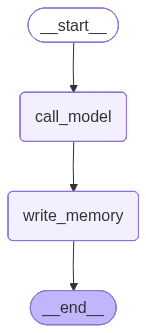

In [47]:
# Define the graph
builder = StateGraph(MessagesState)
builder.add_node("call_model", call_model)
builder.add_node("write_memory", write_memory)
builder.add_edge(START, "call_model")
builder.add_edge("call_model", "write_memory")
builder.add_edge("write_memory", END)

across_thread_memory = InMemoryStore()
within_thread_memory = InMemorySaver()

graph = builder.compile(checkpointer=within_thread_memory, store=across_thread_memory)
display(Image(graph.get_graph(xray=1).draw_mermaid_png()))


In [48]:
# Call the graph
config: RunnableConfig = {"configurable": {"thread_id": "1", "user_id": "1"}}

# User input
input_messages: MessagesState = {"messages": [
    HumanMessage(content="Hi my name is Martin, and I really like basketball")
]}

# Run the graph
for chunk in graph.stream(input_messages, config, stream_mode="values"):
    chunk["messages"][-1].pretty_print()

================================ Human Message =================================

Hi my name is Martin, and I really like basketball
================================== Ai Message ==================================

Nice to meet you, Martin. I've taken note of your name and interest in basketball. How about we start by talking about your favorite team or player? Are you a fan of the NBA, college hoops, or something else? 

Also, I'll make sure to remember this conversation so that I can personalize my responses for you in the future.


BadRequestError: Error code: 400 - {'error': {'message': "Failed to call a function. Please adjust your prompt. See 'failed_generation' for more details.", 'type': 'invalid_request_error', 'code': 'tool_use_failed', 'failed_generation': '<function=UserProfile> {"name": "Martin", "interests": ["basketball"]}'}}

In [ ]:
# Check if it matches the schema
# Namespace for the memory to save
user_id = "1"
namespace = ("memory", user_id)
existing_memory = across_thread_memory.get(namespace, "user_memory")
if existing_memory is not None:
    print(existing_memory.value)

In [ ]:
%load_ext watermark
%watermark

Last updated: 2026-06-08T21:06:12.798227+08:00

Python implementation: CPython
Python version       : 3.12.13
IPython version      : 9.13.0

Compiler    : MSC v.1944 64 bit (AMD64)
OS          : Windows
Release     : 11
Machine     : AMD64
Processor   : Intel64 Family 6 Model 183 Stepping 1, GenuineIntel
CPU cores   : 16
Architecture: 64bit

